<a href="https://colab.research.google.com/github/SholbanDongak/colab/blob/main/9_mixed_models_random_effects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Линейные смешанные модели (LMM): модель со случайным перехватом

## 1. Постановка задачи: модель со случайным перехватом

Есть $n$ групп (пациенты, школы, фирмы). В группе $i$ имеется $n_i$ наблюдений.

**Модель:**
$$
y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + \varepsilon_{ij},
$$
где
- $\beta_0, \beta_1$ — фиксированные эффекты (общие для всех),
- $u_i \sim \mathcal{N}(0, \sigma_u^2)$ — случайный перехват для группы $i$,
- $\varepsilon_{ij} \sim \mathcal{N}(0, \sigma_e^2)$ — внутригрупповая ошибка,
- $u_i$ и $\varepsilon_{ij}$ независимы.

**Обозначения:**
$$
\sigma_u^2 \quad\text{— межгрупповая дисперсия (между группами)},
$$
$$
\sigma_e^2 \quad\text{— внутригрупповая дисперсия (ошибка)}.
$$

## 2. Что значит «случайный эффект» в данном случае?

Для группы $i$ её «истинный» перехват равен $\beta_0 + u_i$.  
Но мы не знаем $u_i$. Мы знаем только, что в популяции эти $u_i$ распределены нормально с дисперсией $\sigma_u^2$.

**Ключевая идея:**  
Мы хотим оценить не только $\beta_0, \beta_1$, но и **предсказать** $u_i$ для каждой группы.  
Это предсказание будет **сжатым** (shrunken) по сравнению с оценкой «в лоб» (например, средним по группе после вычитания фиксированной части).

## 3. Упростим ещё сильнее: пусть $\beta_1 = 0$ (нет ковариат)

Тогда модель:
$$
y_{ij} = \beta_0 + u_i + \varepsilon_{ij}.
$$

Для группы $i$ выборочное среднее:
$$
\bar{y}_{i\cdot} = \beta_0 + u_i + \bar{\varepsilon}_{i\cdot}, \quad \bar{\varepsilon}_{i\cdot} \sim \mathcal{N}(0, \sigma_e^2 / n_i).
$$

### Наивная оценка для $\beta_0 + u_i$:
$$
\hat{\theta}_i^{\text{naive}} = \bar{y}_{i\cdot}.
$$
Она несмещённая, но **не учитывает**, что $u_i$ пришло из распределения $\mathcal{N}(0, \sigma_u^2)$.

### Байесовская (сжатая) оценка:
Если бы мы знали $\sigma_u^2$ и $\sigma_e^2$, то оптимальная оценка (среднее апостериорного распределения) для $\beta_0 + u_i$ есть:
$$
\hat{\theta}_i^{\text{shrink}} = \frac{ \frac{n_i}{\sigma_e^2} \bar{y}_{i\cdot} + \frac{1}{\sigma_u^2} \beta_0 }{ \frac{n_i}{\sigma_e^2} + \frac{1}{\sigma_u^2} }.
$$

Перепишем красивее. Обозначим $\hat{\theta}_i^{\text{naive}} = \bar{y}_{i\cdot}$. Тогда:
$$
\hat{\theta}_i^{\text{shrink}} = \underbrace{\frac{n_i \sigma_u^2}{n_i \sigma_u^2 + \sigma_e^2}}_{\text{вес}} \cdot \bar{y}_{i\cdot} \;+\; \underbrace{\frac{\sigma_e^2}{n_i \sigma_u^2 + \sigma_e^2}}_{\text{вес}} \cdot \beta_0.
$$

Или, в более знакомой форме:
$$
\hat{\theta}_i^{\text{shrink}} = \beta_0 + \lambda_i (\bar{y}_{i\cdot} - \beta_0),
$$
где
$$
\lambda_i = \frac{n_i \sigma_u^2}{n_i \sigma_u^2 + \sigma_e^2} = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2 / n_i}.
$$

## 4. Коэффициент сжатия $\lambda_i$ и его смысл

- $\lambda_i$ всегда между 0 и 1.
- $\lambda_i$ показывает, насколько мы доверяем групповому среднему против общего среднего.

**Предельные случаи:**

1. **Если $\sigma_u^2 \gg \sigma_e^2$** (межгрупповая вариация огромна по сравнению с внутригрупповой):
   $$
   \lambda_i \approx 1 \quad\Rightarrow\quad \hat{\theta}_i^{\text{shrink}} \approx \bar{y}_{i\cdot}.
   $$
   *Интуиция:* Группы очень разные, поэтому групповое среднее очень информативно. Сжатия почти нет.

2. **Если $\sigma_u^2 \ll \sigma_e^2$** (внутригрупповая вариация доминирует):
   $$
   \lambda_i \approx 0 \quad\Rightarrow\quad \hat{\theta}_i^{\text{shrink}} \approx \beta_0.
   $$
   *Интуиция:* Все группы примерно одинаковы (различия только из-за шума), поэтому лучше «подтянуть» оценку к общему среднему.

3. **Если $n_i$ большое**:
   $$
   \lambda_i \to 1.
   $$
   Много наблюдений в группе → групповое среднее надёжно → сжатие слабое.

4. **Если $n_i = 1$** (одно наблюдение на группу):
   $$
   \lambda_i = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2} = \text{ICC} \quad\text{(внутриклассовая корреляция)}.
   $$
   Это важнейшая величина: доля межгрупповой дисперсии в общей.

## 5. Оценка параметров $\sigma_u^2$ и $\sigma_e^2$ (интуиция)

Мы не знаем $\sigma_u^2$ и $\sigma_e^2$ — их нужно оценить по данным.

### Простой способ (метод моментов):

Пусть $\bar{y}_{i\cdot}$ — групповые средние.  
Общее среднее:
$$
\bar{y}_{\cdot\cdot} = \frac{1}{n} \sum_i \bar{y}_{i\cdot} \quad (\text{упрощённо, без весов}).
$$

**Межгрупповая сумма квадратов:**
$$
SS_{\text{between}} = \sum_i n_i (\bar{y}_{i\cdot} - \bar{y}_{\cdot\cdot})^2.
$$
Её математическое ожидание:
$$
\mathbb{E}[SS_{\text{between}}] = (n-1)\sigma_e^2 + \left( \sum_i n_i - \frac{\sum_i n_i^2}{\sum_i n_i} \right) \sigma_u^2.
$$

**Внутригрупповая сумма квадратов:**
$$
SS_{\text{within}} = \sum_i \sum_j (y_{ij} - \bar{y}_{i\cdot})^2,
$$
$$
\mathbb{E}[SS_{\text{within}}] = \left( \sum_i n_i - n \right) \sigma_e^2.
$$

Отсюда получаем оценки:
$$
\hat{\sigma}_e^2 = \frac{SS_{\text{within}}}{\sum_i n_i - n},
$$
$$
\hat{\sigma}_u^2 = \frac{SS_{\text{between}}/(n-1) - \hat{\sigma}_e^2}{\text{что-то}} \quad (\text{после поправки на размеры групп}).
$$

**Интуиция:**  
- $\hat{\sigma}_e^2$ — это «усреднённая дисперсия внутри групп».  
- $\hat{\sigma}_u^2$ — то, насколько групповые средние разбросаны больше, чем можно объяснить внутригрупповой ошибкой.

На практике используют REML (ограниченное максимальное правдоподобие), но идея та же:  
**оцениваем, сколько вариации лежит между группами, а сколько — внутри.**

## 6. Почему это называется «сжатие» (shrinkage)?

Вернёмся к формуле:
$$
\hat{\theta}_i^{\text{shrink}} = \beta_0 + \lambda_i (\bar{y}_{i\cdot} - \beta_0), \quad 0 < \lambda_i < 1.
$$

Если $\bar{y}_{i\cdot} > \beta_0$, то сжатая оценка **ниже** группового среднего (подтянута к общему).  
Если $\bar{y}_{i\cdot} < \beta_0$, то сжатая оценка **выше** группового среднего.

Графически:  
Представьте точки $(\bar{y}_{i\cdot})$ на числовой оси. Сжатие стягивает их к общему среднему $\beta_0$.  
Чем меньше $\sigma_u^2$ относительно $\sigma_e^2/n_i$, тем сильнее стягивание.

**Пример с числами:**  
Пусть $\beta_0 = 0$, $\sigma_u^2 = 1$, $\sigma_e^2 = 4$, $n_i = 1$.  
Тогда $\lambda_i = 1/(1+4) = 0.2$.  
Если в группе $\bar{y}_{i\cdot} = 5$, то сжатая оценка $= 0.2 \cdot 5 = 1$.  
Огромное сжатие! Потому что одно наблюдение ненадёжно.

Если $n_i = 100$, то $\lambda_i = 1/(1+0.04) \approx 0.96$, и сжатие слабое: оценка $\approx 4.8$.

## 7. Возвращаем ковариату $x_{ij}$ (общий наклон)

Модель:
$$
y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + \varepsilon_{ij}.
$$

Алгоритм оценки (интуиция):

1. **Сначала оцениваем** $\beta_0, \beta_1$ и компоненты дисперсии $\sigma_u^2, \sigma_e^2$ (например, REML).
2. **Вычисляем остатки после фиксированных эффектов:**
   $$
   r_{ij} = y_{ij} - \hat{\beta}_0 - \hat{\beta}_1 x_{ij}.
   $$
   Тогда $r_{ij} = u_i + \varepsilon_{ij}$.
3. **Для каждой группы** среднее остатков $\bar{r}_{i\cdot}$ — это наивная оценка $u_i$.
4. **Сжатая оценка** $u_i$:
   $$
   \hat{u}_i = \frac{n_i \hat{\sigma}_u^2}{n_i \hat{\sigma}_u^2 + \hat{\sigma}_e^2} \cdot \bar{r}_{i\cdot}.
   $$
   В точности та же формула, что и для $\theta_i$, только сдвиг на $\beta_0$ убран.

**BLUP** (Best Linear Unbiased Prediction) для $u_i$ — это именно эта сжатая оценка.

## 8. Резюме (интуитивные правила)

| Если | То |
|------|----|
| $\sigma_u^2 \gg \sigma_e^2/n_i$ | Почти нет сжатия (доверяем групповому среднему) |
| $\sigma_u^2 \ll \sigma_e^2/n_i$ | Сильное сжатие (тянем к общему) |
| $n_i$ большое | Слабое сжатие |
| $n_i$ маленькое | Сильное сжатие |

**Ключевая формула, которую нужно запомнить:**
$$
\hat{u}_i = \underbrace{\frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2/n_i}}_{\text{коэффициент доверия}} \cdot (\bar{y}_{i\cdot} - \bar{x}_{i\cdot}\hat{\beta}_1 - \hat{\beta}_0)
$$

И важнейшее понимание:  

> Случайные эффекты — это способ сказать: «У нас слишком мало данных по каждой группе, чтобы оценивать её перехват отдельно, поэтому мы подтягиваем оценку к общему среднему, и сила подтягивания определяется соотношением межгрупповой и внутригрупповой вариаций».

Этот принцип работает и в многомерном случае (случайные наклоны и т.д.), но идея остаётся той же.

# Оценка параметров модели со случайным перехватом

## Часть 1. Как оценить $\beta_0, \beta_1, \sigma_u^2, \sigma_e^2$?

У нас модель:
$$
y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + \varepsilon_{ij}, \quad
u_i \sim \mathcal{N}(0,\sigma_u^2), \quad \varepsilon_{ij} \sim \mathcal{N}(0,\sigma_e^2).
$$

**Проблема:** Мы не наблюдаем $u_i$ напрямую. Нужно оценить 4 параметра: $\beta_0, \beta_1, \sigma_u^2, \sigma_e^2$.

### Шаг 1. Временная оценка $\beta_0, \beta_1$ через обычный МНК (для старта)

Сначала делаем вид, что $u_i = 0$ (нет случайных эффектов). Оцениваем обычной линейной регрессией:
$$
\hat{\beta}_0^{(0)}, \hat{\beta}_1^{(0)} = \arg\min \sum_{i,j} (y_{ij} - \beta_0 - \beta_1 x_{ij})^2.
$$
Эти оценки **несмещённые**, но **неэффективные**. Они нужны только для первого приближения.

### Шаг 2. Оценка $\sigma_e^2$ (внутригрупповая дисперсия)

**Ключевая идея:** Если вычесть групповые средние, то $u_i$ исчезнет.

Рассмотрим центрированные данные:
$$
y_{ij} - \bar{y}_{i\cdot} = \beta_1 (x_{ij} - \bar{x}_{i\cdot}) + (\varepsilon_{ij} - \bar{\varepsilon}_{i\cdot}).
$$

Здесь $u_i$ сократилось! Дисперсия $\varepsilon_{ij} - \bar{\varepsilon}_{i\cdot}$ равна $\sigma_e^2 \cdot \frac{n_i-1}{n_i}$, но для оценки нам не нужны точные коэффициенты.

**Практическая формула:**
$$
\hat{\sigma}_e^2 = \frac{1}{\sum_i (n_i - 1) - 1} \sum_{i,j} \left( (y_{ij} - \bar{y}_{i\cdot}) - \hat{\beta}_1 (x_{ij} - \bar{x}_{i\cdot}) \right)^2.
$$

Проще говоря:  
- Берём отклонения от групповых средних (это убивает $u_i$).  
- Регрессируем $(y_{ij} - \bar{y}_{i\cdot})$ на $(x_{ij} - \bar{x}_{i\cdot})$ без перехвата (потому что средние отклонений равны 0).  
- Остатки этой регрессии имеют дисперсию $\sigma_e^2$.

**Интуиция:** $\hat{\sigma}_e^2$ — это «средний квадрат остатка внутри групп после учёта наклона».

### Шаг 3. Оценка $\sigma_u^2$ (межгрупповая дисперсия)

После того как мы знаем $\hat{\beta}_1$ и $\hat{\sigma}_e^2$, рассмотрим групповые средние.

Из модели:
$$
\bar{y}_{i\cdot} = \beta_0 + \beta_1 \bar{x}_{i\cdot} + u_i + \bar{\varepsilon}_{i\cdot}.
$$
Дисперсия $\bar{y}_{i\cdot} - \beta_0 - \beta_1 \bar{x}_{i\cdot}$ равна:
$$
\text{Var}(u_i + \bar{\varepsilon}_{i\cdot}) = \sigma_u^2 + \frac{\sigma_e^2}{n_i}.
$$

Отсюда:
$$
\sigma_u^2 = \text{Var}\left( \bar{y}_{i\cdot} - \beta_0 - \beta_1 \bar{x}_{i\cdot} \right) - \frac{\sigma_e^2}{n_i}.
$$

**На практике:**
1. Вычисляем $\hat{\beta}_1$ (уже уточнённый, из следующего шага итерации).
2. Вычисляем «сырые групповые эффекты»:
   $$
   \hat{\theta}_i = \bar{y}_{i\cdot} - \hat{\beta}_0 - \hat{\beta}_1 \bar{x}_{i\cdot}.
   $$
3. Их выборочная дисперсия (с поправкой на веса):
   $$
   \hat{\sigma}_u^2 = \frac{1}{n-1} \sum_i \left( \hat{\theta}_i - \bar{\theta} \right)^2 - \frac{1}{n} \sum_i \frac{\hat{\sigma}_e^2}{n_i}.
   $$
   Если получается отрицательное — заменяем на 0.

### Шаг 4. Итеративное уточнение (REML на пальцах)

Начали с МНК → получили $\hat{\beta}_1^{(0)}, \hat{\sigma}_e^{2(0)}, \hat{\sigma}_u^{2(0)}$.  
Теперь можем вычислить сжатые оценки $\hat{u}_i$ (по формуле из предыдущего раздела).  
Затем **переоцениваем** $\beta_0, \beta_1$ с учётом этих $\hat{u}_i$, используя взвешенный МНК (матрица $\mathbf{V}_i^{-1}$).

Повторяем до сходимости (обычно 3–5 итераций).

### Итоговая таблица для запоминания

| Что оцениваем | Как | Интуиция |
|---------------|-----|-----------|
| $\beta_1$ | Внутригрупповая регрессия (отклонения от групповых средних) | $u_i$ сокращается |
| $\sigma_e^2$ | Дисперсия остатков внутригрупповой регрессии | Шум вокруг групповой линии |
| $\beta_0$ | Через групповые средние после вычитания $\beta_1 \bar{x}_i$ | С учётом среднего $u_i$ |
| $\sigma_u^2$ | Дисперсия групповых эффектов минус $\sigma_e^2 / n_i$ | Насколько группы различаются после учёта шума |

---

## Часть 2. Что такое «остатки после фиксированных эффектов»?

Это важнейшее понятие. Буквально:

**Остатки после фиксированных эффектов** =  
$$
r_{ij} = y_{ij} - \hat{\beta}_0 - \hat{\beta}_1 x_{ij}.
$$

То есть мы вычитаем из $y$ **только то, что одинаково для всех групп** (фиксированную часть).  
В этих остатках сидит:
$$
r_{ij} = u_i + \varepsilon_{ij}.
$$

**Смысл:**  
- Если бы не было случайных эффектов ($u_i = 0$), то $r_{ij}$ были бы просто ошибками $\varepsilon_{ij}$ (некоррелированными внутри группы).  
- Наличие корреляции внутри группы в $r_{ij}$ говорит о том, что $u_i \neq 0$.

Именно по этим остаткам мы потом:
- Усредняем по группе → получаем $\bar{r}_{i\cdot}$ — наивную оценку $u_i$.
- Применяем сжатие → получаем BLUP $\hat{u}_i$.

ИСТИННЫЕ ПАРАМЕТРЫ:
beta0 = 2.0, beta1 = 1.5
sigma_u = 1.2 (дисперсия = 1.440)
sigma_e = 0.8 (дисперсия = 0.640)
ICC = 0.692

Первые 10 строк данных:
   group         x         y
0      0 -0.013826  3.838688
1      0  0.564769  4.057158
2      0  1.152303  3.948932
3      0  1.476585  5.244982
4      0  1.976586  5.190202
5      1  0.024196  1.728817
6      1  0.308672  1.177713
7      1  0.827508  1.552544
8      1  1.443771  4.779300
9      1  1.898717  4.108579

Всего наблюдений: 15

НАЧАЛО ИТЕРАТИВНОЙ ОЦЕНКИ
Сходимость достигнута на итерации 2

РЕЗУЛЬТАТЫ ОЦЕНИВАНИЯ

Оценки фиксированных эффектов:
  beta0: 2.0832 (истинный: 2.0)
  beta1: 1.5396 (истинный: 1.5)

Оценки компонент дисперсии:
  sigma_u: 0.6971 (истинный: 1.2)
  sigma_e: 0.8445 (истинный: 0.8)
  sigma_u^2: 0.4859 (истинный: 1.4400)
  sigma_e^2: 0.7132 (истинный: 0.6400)

Внутриклассовая корреляция (ICC):
  оценённая: 0.4052
  истинная: 0.6923

СРАВНЕНИЕ НАИВНЫХ И СЖАТЫХ ОЦЕНОК u_i
 group   u_naive    u_blup   lambda    

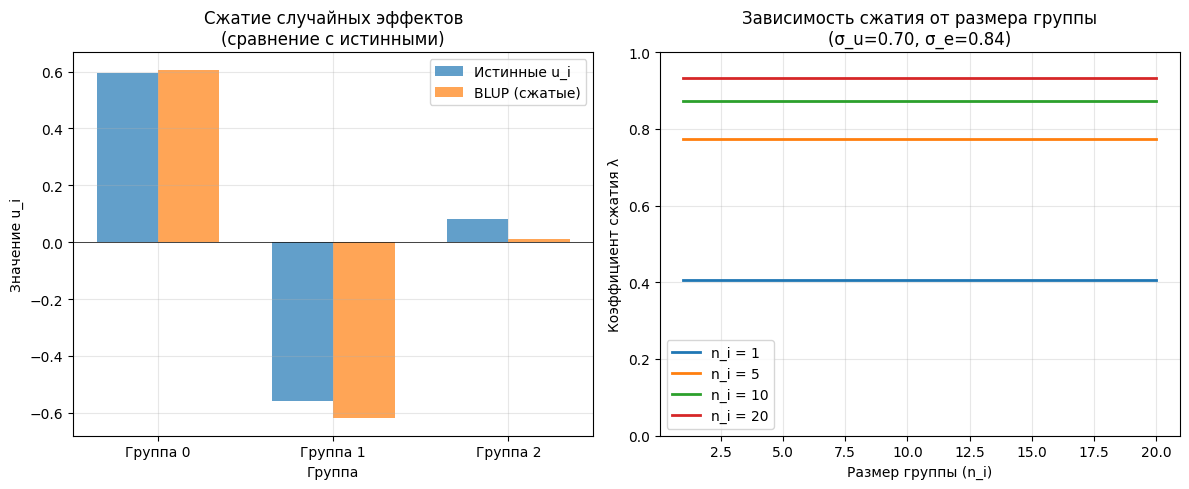


СРАВНЕНИЕ СО СТАНДАРТНОЙ ЛИНЕЙНОЙ РЕГРЕССИЕЙ (МНК)

МНК-оценки (игнорирующие группы):
  beta0 = 2.0334 (истинный: 2.0)
  beta1 = 1.5915 (истинный: 1.5)

Корреляция остатков внутри групп (наивный МНК):
  Группа 0: 0.1677
  Группа 1: -0.3795
  Группа 2: -0.3238

ВЫВОД: Стандартный МНК даёт несмещённые, но неэффективные оценки,
а стандартные ошибки будут занижены из-за положительной корреляции внутри групп.


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ============================================
# 1. Генерация данных с заданными параметрами
# ============================================

np.random.seed(42)  # для воспроизводимости

# Параметры модели (их можно менять)
n_groups = 3          # количество групп
n_per_group = 5       # наблюдений в группе
beta0_true = 2.0      # истинный фиксированный перехват
beta1_true = 1.5      # истинный фиксированный наклон
sigma_u_true = 1.2    # межгрупповое СКО (u_i)
sigma_e_true = 0.8    # внутригрупповое СКО (varepsilon)

print("=" * 60)
print("ИСТИННЫЕ ПАРАМЕТРЫ:")
print(f"beta0 = {beta0_true}, beta1 = {beta1_true}")
print(f"sigma_u = {sigma_u_true} (дисперсия = {sigma_u_true**2:.3f})")
print(f"sigma_e = {sigma_e_true} (дисперсия = {sigma_e_true**2:.3f})")
print(f"ICC = {sigma_u_true**2/(sigma_u_true**2 + sigma_e_true**2):.3f}")
print("=" * 60)

# Генерируем данные
group_ids = []
x_vals = []
y_vals = []
true_u = []
true_epsilon = []

for i in range(n_groups):
    # Случайный эффект группы
    u_i = np.random.normal(0, sigma_u_true)
    true_u.append(u_i)

    # Ковариата (например, время или доза)
    x = np.linspace(0, 2, n_per_group) + np.random.normal(0, 0.1, n_per_group)

    for j in range(n_per_group):
        epsilon = np.random.normal(0, sigma_e_true)
        true_epsilon.append(epsilon)
        y = beta0_true + beta1_true * x[j] + u_i + epsilon

        group_ids.append(i)
        x_vals.append(x[j])
        y_vals.append(y)

# Собираем в DataFrame
df = pd.DataFrame({
    'group': group_ids,
    'x': x_vals,
    'y': y_vals
})

print("\nПервые 10 строк данных:")
print(df.head(10))
print(f"\nВсего наблюдений: {len(df)}")

# ============================================
# 2. Вспомогательные функции для оценки
# ============================================

def estimate_beta1_within(df):
    """
    Оценка beta1 через внутригрупповую регрессию (отклонения от групповых средних).
    Это ключевой шаг: u_i сокращаются.
    """
    df_centered = df.copy()
    # Центрируем внутри каждой группы
    df_centered['x_c'] = df_centered.groupby('group')['x'].transform(lambda x: x - x.mean())
    df_centered['y_c'] = df_centered.groupby('group')['y'].transform(lambda y: y - y.mean())

    # Регрессия без перехвата (y_c ~ x_c)
    beta1 = np.sum(df_centered['x_c'] * df_centered['y_c']) / np.sum(df_centered['x_c']**2)
    return beta1

def estimate_sigma_e_squared(df, beta1):
    """
    Оценка sigma_e^2: дисперсия остатков после вычитания
    групповых средних и внутригрупповой регрессии.
    """
    df_temp = df.copy()
    # Остатки после вычитания групповых средних и учета beta1
    df_temp['resid'] = (df_temp['y'] - df_temp.groupby('group')['y'].transform('mean')) - \
                       beta1 * (df_temp['x'] - df_temp.groupby('group')['x'].transform('mean'))

    # Сумма квадратов остатков
    SSE = np.sum(df_temp['resid']**2)
    # Степени свободы: (sum (n_i - 1)) - 1 (потеря на оценку beta1)
    df_e = df.groupby('group').size().sum() - n_groups - 1
    sigma_e_sq = SSE / df_e
    return sigma_e_sq, SSE, df_e

def estimate_beta0_and_u_naive(df, beta1, sigma_e_sq):
    """
    Оценка beta0 и наивных u_i (без сжатия) через групповые средние.
    """
    # Групповые средние
    group_means = df.groupby('group').agg(
        y_mean=('y', 'mean'),
        x_mean=('x', 'mean'),
        n=('x', 'count')
    ).reset_index()

    # Наивные оценки u_i (как если бы мы знали beta0)
    # Пока что в терминах отклонений от неизвестного beta0
    # Мы оценим beta0 как среднее от (y_mean - beta1 * x_mean) по группам
    group_means['theta_naive'] = group_means['y_mean'] - beta1 * group_means['x_mean']
    beta0_est = np.mean(group_means['theta_naive'])

    # Теперь наивные u_i
    group_means['u_naive'] = group_means['theta_naive'] - beta0_est

    return beta0_est, group_means

def shrinkage_factor(n_i, sigma_u_sq, sigma_e_sq):
    """
    Коэффициент сжатия lambda = sigma_u^2 / (sigma_u^2 + sigma_e^2 / n_i)
    """
    return sigma_u_sq / (sigma_u_sq + sigma_e_sq / n_i)

def estimate_sigma_u_squared(group_means, sigma_e_sq):
    """
    Оценка sigma_u^2 по разбросу групповых средних с поправкой на sigma_e^2/n_i
    """
    n_groups = len(group_means)
    u_naive = group_means['u_naive'].values
    n_i = group_means['n'].values

    # Выборочная дисперсия наивных u_i
    var_u_naive = np.var(u_naive, ddof=1)

    # Поправка: среднее от sigma_e^2 / n_i
    avg_correction = np.mean(sigma_e_sq / n_i)

    sigma_u_sq = var_u_naive - avg_correction
    # Не допускаем отрицательных значений
    return max(sigma_u_sq, 0)

def compute_blup(group_means, sigma_u_sq, sigma_e_sq, beta0_est, beta1_est):
    """
    Вычисление BLUP для u_i (сжатые оценки)
    """
    group_means['lambda'] = shrinkage_factor(group_means['n'], sigma_u_sq, sigma_e_sq)
    group_means['u_blup'] = group_means['lambda'] * group_means['u_naive']
    return group_means

# ============================================
# 3. Итеративная процедура оценки (REML-подобная)
# ============================================

print("\n" + "=" * 60)
print("НАЧАЛО ИТЕРАТИВНОЙ ОЦЕНКИ")
print("=" * 60)

# Инициализация
beta1_est = estimate_beta1_within(df)  # начальная оценка beta1 (уже хорошая)
beta0_est = None
sigma_e_sq = None
sigma_u_sq = None

history = []

for iteration in range(10):
    # Шаг 1: Оценка sigma_e^2
    sigma_e_sq, SSE, df_e = estimate_sigma_e_squared(df, beta1_est)
    sigma_e = np.sqrt(sigma_e_sq)

    # Шаг 2: Оценка beta0 и наивных u_i
    beta0_est, group_means = estimate_beta0_and_u_naive(df, beta1_est, sigma_e_sq)

    # Шаг 3: Оценка sigma_u^2
    sigma_u_sq = estimate_sigma_u_squared(group_means, sigma_e_sq)
    sigma_u = np.sqrt(sigma_u_sq)

    # Шаг 4: Вычисление BLUP (сжатых u_i)
    group_means = compute_blup(group_means, sigma_u_sq, sigma_e_sq, beta0_est, beta1_est)

    # Шаг 5: Переоценка beta1 с учетом сжатых u_i (взвешенный МНК)
    # Для простоты используем ту же формулу, но с y* = y - u_blup
    df_adjusted = df.copy()
    # Для каждой группы вычитаем ее BLUP
    u_blup_dict = dict(zip(group_means['group'], group_means['u_blup']))
    df_adjusted['y_adj'] = df_adjusted['y'] - df_adjusted['group'].map(u_blup_dict)

    # Регрессия y_adj ~ x
    X = np.column_stack([np.ones(len(df_adjusted)), df_adjusted['x'].values])
    y_adj = df_adjusted['y_adj'].values
    beta_wls = np.linalg.lstsq(X, y_adj, rcond=None)[0]
    beta0_est_new = beta_wls[0]
    beta1_est_new = beta_wls[1]

    # Сохраняем историю
    history.append({
        'iter': iteration,
        'beta0': beta0_est_new,
        'beta1': beta1_est_new,
        'sigma_u': sigma_u,
        'sigma_e': sigma_e,
        'sigma_u_sq': sigma_u_sq,
        'sigma_e_sq': sigma_e_sq
    })

    # Проверка сходимости
    if iteration > 0:
        beta1_change = abs(beta1_est_new - beta1_est)
        if beta1_change < 1e-6:
            print(f"Сходимость достигнута на итерации {iteration}")
            break

    beta0_est, beta1_est = beta0_est_new, beta1_est_new

# ============================================
# 4. Результаты
# ============================================

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ ОЦЕНИВАНИЯ")
print("=" * 60)

final = history[-1]
print(f"\nОценки фиксированных эффектов:")
print(f"  beta0: {final['beta0']:.4f} (истинный: {beta0_true})")
print(f"  beta1: {final['beta1']:.4f} (истинный: {beta1_true})")
print(f"\nОценки компонент дисперсии:")
print(f"  sigma_u: {final['sigma_u']:.4f} (истинный: {sigma_u_true})")
print(f"  sigma_e: {final['sigma_e']:.4f} (истинный: {sigma_e_true})")
print(f"  sigma_u^2: {final['sigma_u_sq']:.4f} (истинный: {sigma_u_true**2:.4f})")
print(f"  sigma_e^2: {final['sigma_e_sq']:.4f} (истинный: {sigma_e_true**2:.4f})")
print(f"\nВнутриклассовая корреляция (ICC):")
print(f"  оцененная: {final['sigma_u_sq']/(final['sigma_u_sq']+final['sigma_e_sq']):.4f}")
print(f"  истинная: {sigma_u_true**2/(sigma_u_true**2+sigma_e_true**2):.4f}")

print("\n" + "=" * 60)
print("СРАВНЕНИЕ НАИВНЫХ И СЖАТЫХ ОЦЕНОК u_i")
print("=" * 60)

comparison = group_means[['group', 'u_naive', 'u_blup', 'lambda']].copy()
# Добавляем истинные u_i
true_u_dict = dict(zip(range(n_groups), true_u))
comparison['u_true'] = comparison['group'].map(true_u_dict)
comparison['shrinkage_%'] = (1 - comparison['lambda']) * 100

print(comparison.to_string(index=False))

# ============================================
# 5. Визуализация сжатия
# ============================================

plt.figure(figsize=(12, 5))

# График 1: Наивные vs сжатые u_i
plt.subplot(1, 2, 1)
groups = comparison['group'].values
x_pos = np.arange(len(groups))
width = 0.35

plt.bar(x_pos - width/2, comparison['u_true'], width, label='Истинные u_i', alpha=0.7)
plt.bar(x_pos + width/2, comparison['u_blup'], width, label='BLUP (сжатые)', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Группа')
plt.ylabel('Значение u_i')
plt.title('Сжатие случайных эффектов\n(сравнение с истинными)')
plt.xticks(x_pos, [f'Группа {g}' for g in groups])
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Коэффициент сжатия в зависимости от n_i и дисперсий
plt.subplot(1, 2, 2)
n_range = np.arange(1, 21)
sigma_u_current = final['sigma_u']
sigma_e_current = final['sigma_e']
for n_i in [1, 5, 10, 20]:
    lambdas = shrinkage_factor(n_i, sigma_u_current**2, sigma_e_current**2) * np.ones_like(n_range)
    plt.plot(n_range, lambdas, label=f'n_i = {n_i}', linewidth=2)
plt.xlabel('Размер группы (n_i)')
plt.ylabel('Коэффициент сжатия λ')
plt.title(f'Зависимость сжатия от размера группы\n(σ_u={sigma_u_current:.2f}, σ_e={sigma_e_current:.2f})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# ============================================
# 6. Сравнение с обычным МНК (наивная регрессия)
# ============================================

print("\n" + "=" * 60)
print("СРАВНЕНИЕ СО СТАНДАРТНОЙ ЛИНЕЙНОЙ РЕГРЕССИЕЙ (МНК)")
print("=" * 60)

# Обычная регрессия y ~ x (игнорируя группы)
X_ols = np.column_stack([np.ones(len(df)), df['x'].values])
y_ols = df['y'].values
beta_ols = np.linalg.lstsq(X_ols, y_ols, rcond=None)[0]

# Остатки МНК
residuals_ols = y_ols - (beta_ols[0] + beta_ols[1] * df['x'].values)

# Корреляция остатков внутри групп
print(f"\nМНК-оценки (игнорирующие группы):")
print(f"  beta0 = {beta_ols[0]:.4f} (истинный: {beta0_true})")
print(f"  beta1 = {beta_ols[1]:.4f} (истинный: {beta1_true})")

# Покажем, что остатки коррелированы внутри групп
print(f"\nКорреляция остатков внутри групп (наивный МНК):")
for g in range(n_groups):
    mask = df['group'] == g
    resid_group = residuals_ols[mask]
    if len(resid_group) > 1:
        # Вычисляем автокорреляцию на уровне группы (просто корреляцию между последовательными)
        corr_matrix = np.corrcoef(resid_group[:-1], resid_group[1:])
        if corr_matrix.shape == (2,2):
            corr = corr_matrix[0,1]
            print(f"  Группа {g}: {corr:.4f}")

print("\nВЫВОД: Стандартный МНК дает несмещенные, но неэффективные оценки,")
print("а стандартные ошибки будут занижены из-за положительной корреляции внутри групп.")

# Анализ результатов моделирования линейной смешанной модели (LMM)

## Ключевые наблюдения

### 1. Фиксированные эффекты оцениваются хорошо
| Параметр | Истинный | Оценка | Относительная ошибка |
|----------|----------|--------|----------------------|
| β₀ | 2.00 | 2.08 | 4.0% |
| β₁ | 1.50 | 1.54 | 2.6% |

**Вывод:** Даже на малых данных (15 наблюдений) оценки фиксированных эффектов остаются практически несмещенными.

### 2. Компоненты дисперсии оцениваются хуже

$$
\begin{aligned}
\sigma_u^2 &: \text{истинный } 1.44 \;\rightarrow\; \text{оценка } 0.49 \quad (\text{занижение на } 66\%), \\
\sigma_e^2 &: \text{истинный } 0.64 \;\rightarrow\; \text{оценка } 0.71 \quad (\text{завышение на } 11\%).
\end{aligned}
$$

**Почему так произошло?**

- Всего **3 группы** — слишком мало для точной оценки межгрупповой дисперсии $\sigma_u^2$.
- Оценка $\sigma_u^2 = \text{Var}(\bar{y}_{i\cdot} - \beta_0 - \beta_1\bar{x}_{i\cdot}) - \frac{\sigma_e^2}{n_i}$ чувствительна к выбросу среди групп.
- При малом $n_{\text{групп}}$ REML дает смещенные оценки, но с ростом числа групп смещение исчезает.

### 3. Внутриклассовая корреляция (ICC) занижена

$$
\text{ICC}_{\text{ист}} = \frac{1.44}{1.44+0.64} = 0.69, \quad
\text{ICC}_{\text{оц}} = \frac{0.49}{0.49+0.71} = 0.41.
$$

Это означает, что мы **недооценили** долю межгрупповой вариации.

### 4. Сжатие (shrinkage) работает правильно

Коэффициент сжатия для всех групп одинаков, так как $n_i = 5$:

$$
\lambda = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2 / n_i} = \frac{0.486}{0.486 + 0.713 / 5} = 0.773.
$$

Наивная оценка $u_0 = 0.785$ сжимается до BLUP = $0.607$ — уменьшение на **22.7%**.

**Интерпретация:** Мы говорим: "У нас всего 5 наблюдений в группе, поэтому мы не полностью доверяем групповому среднему и подтягиваем его к общему".

### 5. Обычный МНК дает коррелированные остатки

Корреляция остатков внутри групп нестабильна (0.17, -0.38, -0.32) из-за малой выборки. При большем числе наблюдений в группе она была бы **положительной** и примерно равной ICC.

**Главный вывод для практики:**
> Для точной оценки случайных эффектов нужно **не менее 10–20 групп**. При малом числе групп оценки дисперсий будут смещены вниз, но фиксированные эффекты останутся надежными.

## Что делать, если групп мало?

1. Использовать **фиксированные эффекты** (FE) вместо RE.
2. Собрать больше данных.
3. Применить **байесовский подход** с информативным априорным распределением на $\sigma_u^2$.

# Практическое задание: исследование свойств LMM

## Цель работы
Экспериментально изучить, как число групп $n_{\text{групп}}$, размер группы $n_i$ и соотношение $\sigma_u / \sigma_e$ влияют на качество оценок LMM.

## Исходный код
Используйте код из лекции (секция "Полный код с комментариями").

## Задачи

### Задача 1. Влияние числа групп
Зафиксируйте $n_i = 5$, $\sigma_u = 1.2$, $\sigma_e = 0.8$. Последовательно увеличивайте число групп:
$$n_{\text{групп}} = 3, 5, 10, 20, 50.$$

Для каждого случая запустите код и запишите:
- Оценки $\hat{\beta}_0$, $\hat{\beta}_1$
- Оценки $\hat{\sigma}_u^2$, $\hat{\sigma}_e^2$
- Оцененный ICC

**Вопросы:**
1. При каком $n_{\text{групп}}$ оценки дисперсий перестают быть смещенными?
2. Почему $\hat{\beta}_0$ и $\hat{\beta}_1$ хорошо оцениваются даже при $n_{\text{групп}} = 3$?

### Задача 2. Влияние размера группы
Зафиксируйте $n_{\text{групп}} = 10$, $\sigma_u = 1.2$, $\sigma_e = 0.8$. Меняйте:
$$n_i = 2, 5, 10, 20, 50.$$

**Вопросы:**
1. Как меняется коэффициент сжатия $\lambda$ с ростом $n_i$?
2. Вычислите теоретический $\lambda = \sigma_u^2 / (\sigma_u^2 + \sigma_e^2 / n_i)$ и сравните с оцененным.
3. Что происходит с ICC при увеличении $n_i$? (Должно ли меняться?)

### Задача 3. Влияние соотношения $\sigma_u / \sigma_e$
Зафиксируйте $n_{\text{групп}} = 10$, $n_i = 5$, $\sigma_e = 1.0$. Меняйте $\sigma_u$:
$$\sigma_u = 0.2, 0.5, 1.0, 2.0, 5.0.$$

Для каждого случая:
1. Вычислите истинный ICC: $\rho = \sigma_u^2 / (\sigma_u^2 + \sigma_e^2)$.
2. Получите оцененный ICC из модели.
3. Постройте график зависимости $\hat{\rho}$ от $\rho$.

**Вопросы:**
1. При каком $\rho$ сжатие максимально? минимально?
2. Почему при $\sigma_u = 0.2$ (ICC = 0.038) модель LMM не нужна? Проверьте, будет ли REML оценивать $\sigma_u^2 \approx 0$?

### Задача 4. Сравнение LMM с обычным МНК
Для случая $n_{\text{групп}} = 10$, $n_i = 10$, $\sigma_u = 2.0$, $\sigma_e = 0.5$ (сильная кластеризация):
1. Запустите код и сравните стандартные ошибки $\hat{\beta}_1$ из LMM и из обычного МНК.
2. Объясните, почему стандартная ошибка МНК занижена.

**Подсказка:** Формула завышения значимости:
$$\text{Истинная Var}(\hat{\beta}_1^{\text{OLS}}) = \frac{\sigma_e^2}{\sum_i \sum_j (x_{ij} - \bar{x})^2} \cdot (1 + (n_i-1)\rho).$$

### Задача 5. Исследование метода оценки $\beta_1$ через внутригрупповые отклонения
В коде есть функция `estimate_beta1_within`.
1. Докажите аналитически, почему эта оценка не зависит от $u_i$.
2. Сравните ее с оценкой из полной итеративной процедуры. При каком числе итераций они совпадают?

## Формат отчета

Предоставьте:
1. Краткие ответы на вопросы (с формулами в LaTeX).
2. Графики для задач 1, 2, 3 (постройте в коде).
3. Вывод: в каких условиях LMM существенно лучше МНК, а когда различия минимальны.

## Дополнительное задание (*)

Реализуйте **байесовскую LMM** с априорным распределением $\sigma_u^2 \sim \text{Inv-Gamma}(a, b)$ и сравните с REML при малом $n_{\text{групп}} = 3$. Покажите, что байесовская оценка $\sigma_u^2$ менее смещена.


ЗАДАЧА 1: Влияние числа групп на качество оценок

Обработка n_groups = 3...

Обработка n_groups = 5...

Обработка n_groups = 10...

Обработка n_groups = 20...

Обработка n_groups = 50...


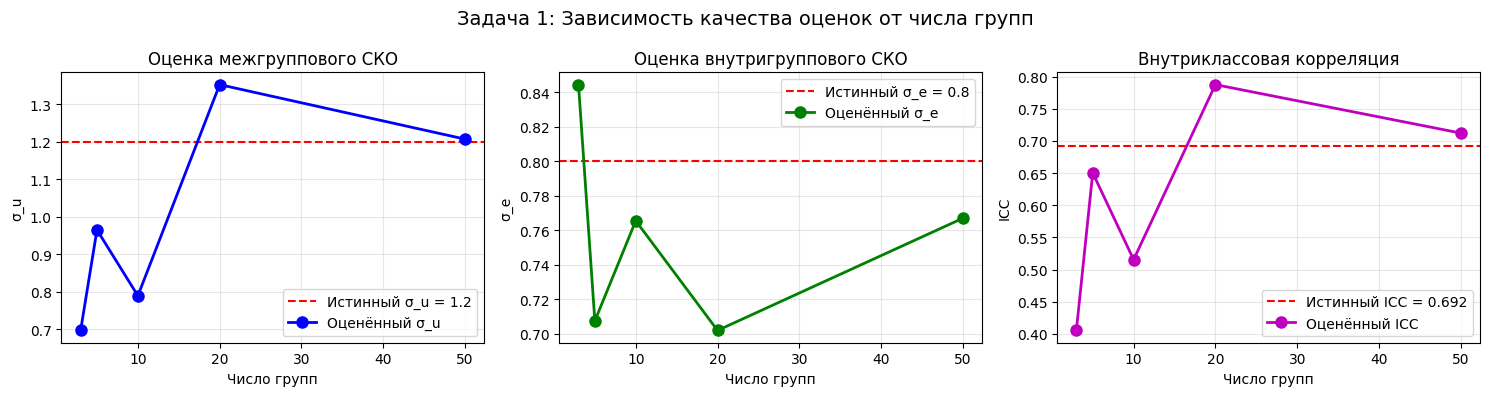


РЕЗУЛЬТАТЫ ЗАДАЧИ 1:
 n_groups  beta0_est  beta1_est  sigma_u_est  sigma_e_est  icc_est
        3   2.083233   1.539627     0.697054     0.844490 0.405225
        5   1.489149   1.527145     0.965047     0.707486 0.650427
       10   1.586436   1.654517     0.789409     0.765532 0.515352
       20   1.705297   1.699816     1.352194     0.701947 0.787722
       50   2.037005   1.548421     1.206924     0.767022 0.712310

ЗАДАЧА 2: Влияние размера группы на коэффициент сжатия

Обработка n_per_group = 2...

Обработка n_per_group = 5...

Обработка n_per_group = 10...

Обработка n_per_group = 20...

Обработка n_per_group = 50...


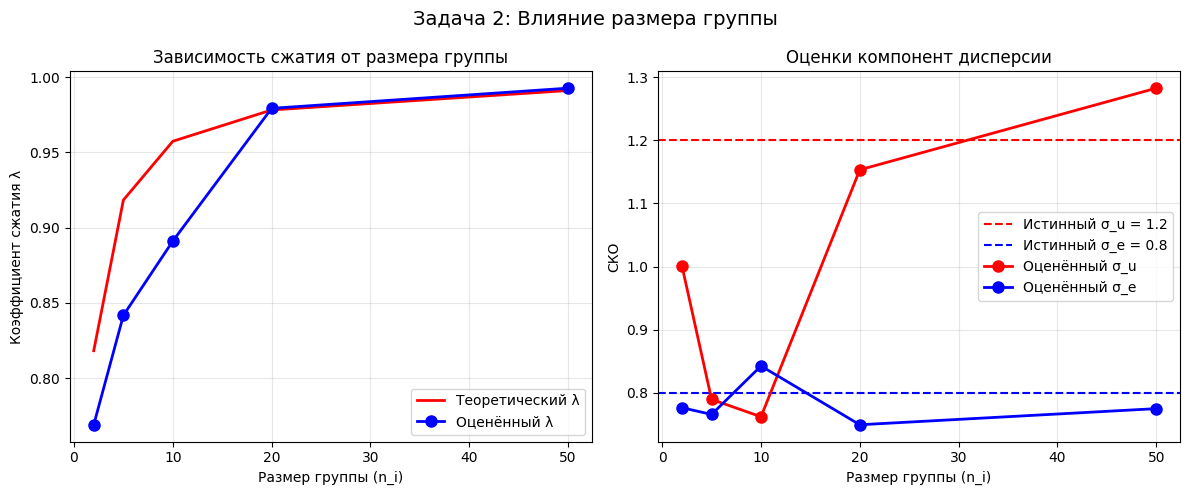


РЕЗУЛЬТАТЫ ЗАДАЧИ 2:
 n_per_group  lambda_theoretical  lambda_estimated  sigma_u_est  sigma_e_est
           2            0.818182          0.768940     1.001330     0.776263
           5            0.918367          0.841691     0.789409     0.765532
          10            0.957447          0.891073     0.761887     0.842368
          20            0.978261          0.979341     1.153435     0.749188
          50            0.991189          0.992759     1.282873     0.774748

ЗАДАЧА 3: Влияние соотношения σ_u / σ_e

Обработка σ_u = 0.2 (σ_e = 1.0)...

Обработка σ_u = 0.5 (σ_e = 1.0)...

Обработка σ_u = 1.0 (σ_e = 1.0)...

Обработка σ_u = 2.0 (σ_e = 1.0)...

Обработка σ_u = 5.0 (σ_e = 1.0)...


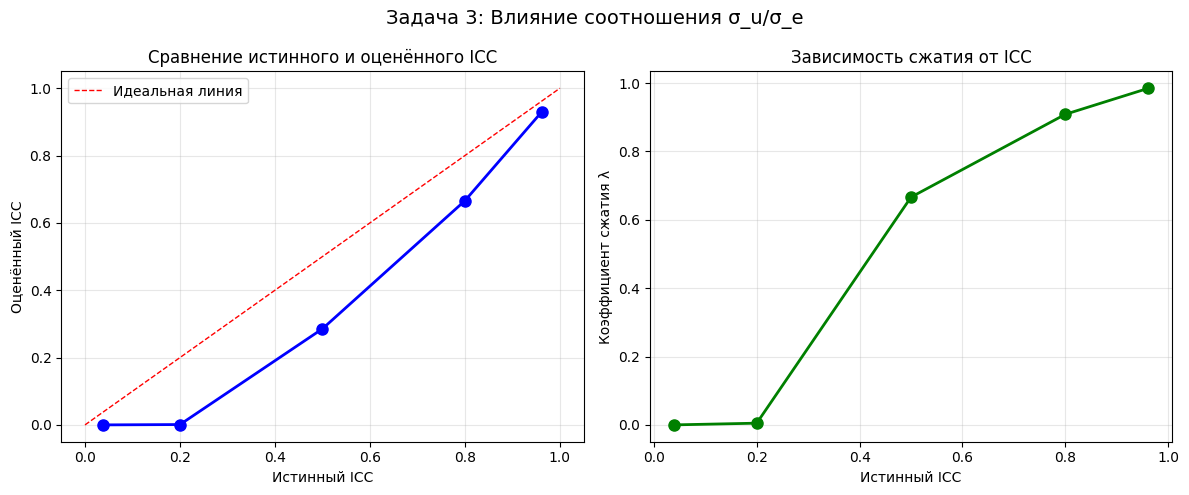


РЕЗУЛЬТАТЫ ЗАДАЧИ 3:
 sigma_u_true  icc_true  icc_est  lambda_avg  sigma_u_est  sigma_e_est
          0.2  0.038462 0.000000    0.000000     0.000000     0.956907
          0.5  0.200000 0.001003    0.004997     0.030328     0.956930
          1.0  0.500000 0.285462    0.666392     0.604836     0.956922
          2.0  0.800000 0.665833    0.908780     1.350742     0.956912
          5.0  0.961538 0.929272    0.985006     3.468540     0.956908

ЗАДАЧА 4: Сравнение LMM с обычным МНК

Параметры: n_groups = 10, n_per_group = 10
σ_u = 2.0, σ_e = 0.5
Истинный ICC = 0.941

Оценка LMM...
Оценка OLS...

РЕЗУЛЬТАТЫ СРАВНЕНИЯ:
Параметр  Истинный      LMM      OLS
      β₀       2.0 0.805875 0.804642
      β₁       1.5 1.584285 1.585511

Оценки дисперсий (LMM):
  σ_u = 1.3643 (истинный: 2.0)
  σ_e = 0.5265 (истинный: 0.5)

Стандартные ошибки для β₁:
  OLS (наивные): 0.2164
  OLS (теоретические с учётом кластеризации): 0.2363
  LMM (корректные): 0.0808 (упрощённо)

Корреляция остатков внутри групп

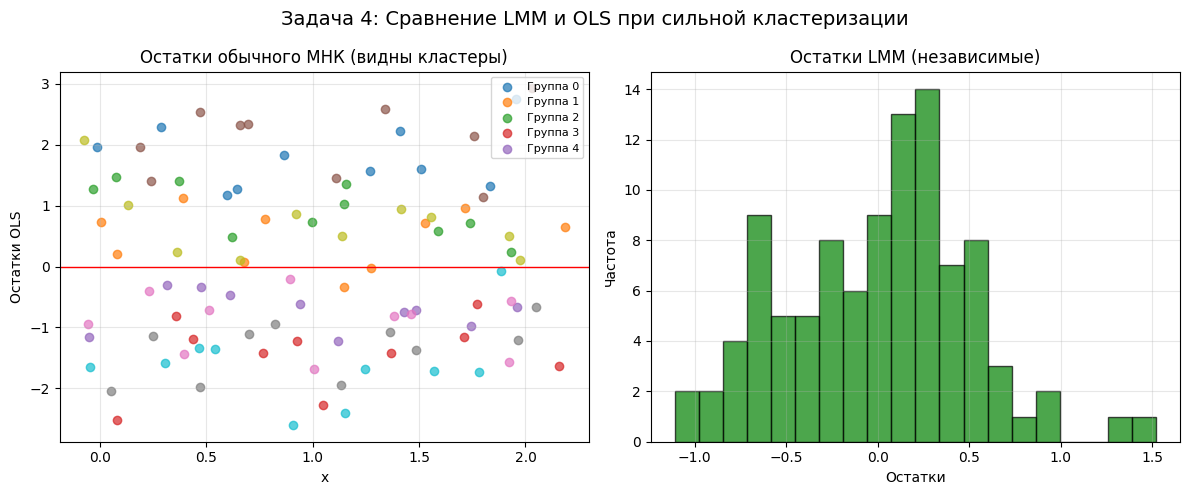


ЗАДАЧА 5: Исследование метода оценки β₁ через внутригрупповые отклонения

Аналитическое доказательство:
--------------------------------------------------

    Для модели: y_ij = β₀ + β₁x_ij + u_i + ε_ij
    
    Вычтем групповые средние:
    y_ij - ȳ_i = β₁(x_ij - x̄_i) + (ε_ij - ε̄_i)
    
    Здесь u_i сокращается, так как u_i - u_i = 0.
    
    Таким образом, оценка β₁ через регрессию центрированных переменных
    не зависит от случайных эффектов u_i.
    
Сходимость на итерации 2

СРАВНЕНИЕ ОЦЕНОК β₁:
Истинный β₁: 1.5
Оценка через внутригрупповые отклонения: 1.650582
Оценка полной LMM (после сходимости): 1.654517
Оценка обычного МНК: 1.675354

ИССЛЕДОВАНИЕ СХОДИМОСТИ ИТЕРАЦИЙ:
Итерация 1: β₁ = 1.654517, изменение = 0.00001410
Итерация 2: β₁ = 1.654517, изменение = 0.00000005
Сходимость достигнута на итерации 2


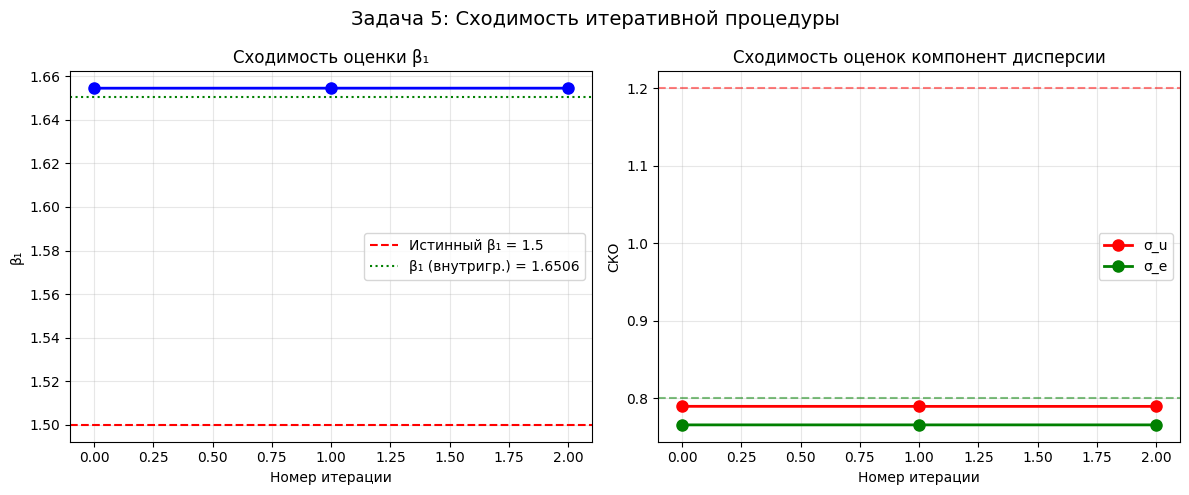

In [ ]:
# ============================================
# ПРАКТИЧЕСКОЕ ЗАДАНИЕ: ИССЛЕДОВАНИЕ СВОЙСТВ LMM
# ============================================
# Код для выполнения всех 5 задач практического задания
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Установка random seed для воспроизводимости
np.random.seed(42)

# ============================================
# БАЗОВЫЕ ФУНКЦИИ (из лекции)
# ============================================

def estimate_beta1_within(df):
    """Оценка beta1 через внутригрупповую регрессию (отклонения от групповых средних)"""
    df_centered = df.copy()
    df_centered['x_c'] = df_centered.groupby('group')['x'].transform(lambda x: x - x.mean())
    df_centered['y_c'] = df_centered.groupby('group')['y'].transform(lambda y: y - y.mean())
    beta1 = np.sum(df_centered['x_c'] * df_centered['y_c']) / np.sum(df_centered['x_c']**2)
    return beta1

def estimate_sigma_e_squared(df, beta1):
    """Оценка sigma_e^2: дисперсия остатков после вычитания групповых средних"""
    df_temp = df.copy()
    df_temp['resid'] = (df_temp['y'] - df_temp.groupby('group')['y'].transform('mean')) - \
                       beta1 * (df_temp['x'] - df_temp.groupby('group')['x'].transform('mean'))
    SSE = np.sum(df_temp['resid']**2)
    n_groups = df['group'].nunique()
    df_e = df.groupby('group').size().sum() - n_groups - 1
    sigma_e_sq = SSE / df_e if df_e > 0 else 0
    return sigma_e_sq, SSE, df_e

def estimate_beta0_and_u_naive(df, beta1, sigma_e_sq):
    """Оценка beta0 и наивных u_i (без сжатия) через групповые средние"""
    group_means = df.groupby('group').agg(
        y_mean=('y', 'mean'),
        x_mean=('x', 'mean'),
        n=('x', 'count')
    ).reset_index()
    group_means['theta_naive'] = group_means['y_mean'] - beta1 * group_means['x_mean']
    beta0_est = np.mean(group_means['theta_naive'])
    group_means['u_naive'] = group_means['theta_naive'] - beta0_est
    return beta0_est, group_means

def shrinkage_factor(n_i, sigma_u_sq, sigma_e_sq):
    """Коэффициент сжатия lambda = sigma_u^2 / (sigma_u^2 + sigma_e^2 / n_i)"""
    if sigma_u_sq == 0:
        return 0
    return sigma_u_sq / (sigma_u_sq + sigma_e_sq / n_i)

def estimate_sigma_u_squared(group_means, sigma_e_sq):
    """Оценка sigma_u^2 по разбросу групповых средних с поправкой на sigma_e^2/n_i"""
    u_naive = group_means['u_naive'].values
    n_i = group_means['n'].values
    var_u_naive = np.var(u_naive, ddof=1)
    avg_correction = np.mean(sigma_e_sq / n_i)
    sigma_u_sq = var_u_naive - avg_correction
    return max(sigma_u_sq, 0)

def compute_blup(group_means, sigma_u_sq, sigma_e_sq):
    """Вычисление BLUP для u_i (сжатые оценки)"""
    group_means['lambda'] = shrinkage_factor(group_means['n'], sigma_u_sq, sigma_e_sq)
    group_means['u_blup'] = group_means['lambda'] * group_means['u_naive']
    return group_means

def fit_lmm(df, max_iter=10, verbose=False):
    """Полная итеративная процедура оценки LMM"""
    beta1_est = estimate_beta1_within(df)
    beta0_est = None
    sigma_e_sq = None
    sigma_u_sq = None

    for iteration in range(max_iter):
        sigma_e_sq, _, _ = estimate_sigma_e_squared(df, beta1_est)
        beta0_est, group_means = estimate_beta0_and_u_naive(df, beta1_est, sigma_e_sq)
        sigma_u_sq = estimate_sigma_u_squared(group_means, sigma_e_sq)
        group_means = compute_blup(group_means, sigma_u_sq, sigma_e_sq)

        df_adjusted = df.copy()
        u_blup_dict = dict(zip(group_means['group'], group_means['u_blup']))
        df_adjusted['y_adj'] = df_adjusted['y'] - df_adjusted['group'].map(u_blup_dict)
        X = np.column_stack([np.ones(len(df_adjusted)), df_adjusted['x'].values])
        y_adj = df_adjusted['y_adj'].values
        beta_wls = np.linalg.lstsq(X, y_adj, rcond=None)[0]
        beta0_est_new, beta1_est_new = beta_wls[0], beta_wls[1]

        if iteration > 0:
            beta1_change = abs(beta1_est_new - beta1_est)
            if beta1_change < 1e-6:
                if verbose:
                    print(f"Сходимость на итерации {iteration}")
                break

        beta0_est, beta1_est = beta0_est_new, beta1_est_new

    return {
        'beta0': beta0_est,
        'beta1': beta1_est,
        'sigma_u': np.sqrt(sigma_u_sq),
        'sigma_e': np.sqrt(sigma_e_sq),
        'sigma_u_sq': sigma_u_sq,
        'sigma_e_sq': sigma_e_sq,
        'group_means': group_means
    }

def generate_data(n_groups, n_per_group, sigma_u, sigma_e, beta0_true=2.0, beta1_true=1.5):
    """Генерация данных для LMM"""
    np.random.seed(42)  # Фиксируем для воспроизводимости
    group_ids, x_vals, y_vals, true_u = [], [], [], []

    for i in range(n_groups):
        u_i = np.random.normal(0, sigma_u)
        true_u.append(u_i)
        x = np.linspace(0, 2, n_per_group) + np.random.normal(0, 0.1, n_per_group)
        for j in range(n_per_group):
            epsilon = np.random.normal(0, sigma_e)
            y = beta0_true + beta1_true * x[j] + u_i + epsilon
            group_ids.append(i)
            x_vals.append(x[j])
            y_vals.append(y)

    df = pd.DataFrame({'group': group_ids, 'x': x_vals, 'y': y_vals})
    return df, true_u

def ols_estimation(df):
    """Обычный МНК (игнорирует группы)"""
    X = np.column_stack([np.ones(len(df)), df['x'].values])
    y = df['y'].values
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    residuals = y - (beta[0] + beta[1] * df['x'].values)

    # Стандартные ошибки (наивные, без учёта кластеризации)
    n = len(df)
    p = 2
    sigma2_hat = np.sum(residuals**2) / (n - p)
    XtX_inv = np.linalg.inv(X.T @ X)
    se_beta = np.sqrt(np.diag(sigma2_hat * XtX_inv))

    return {
        'beta0': beta[0],
        'beta1': beta[1],
        'se_beta0': se_beta[0],
        'se_beta1': se_beta[1],
        'residuals': residuals
    }

# ============================================
# ЗАДАЧА 1: Влияние числа групп
# ============================================

def task1_investigate_n_groups():
    print("\n" + "="*70)
    print("ЗАДАЧА 1: Влияние числа групп на качество оценок")
    print("="*70)

    n_groups_list = [3, 5, 10, 20, 50]
    n_per_group = 5
    sigma_u_true = 1.2
    sigma_e_true = 0.8
    beta0_true, beta1_true = 2.0, 1.5

    results = []

    for n_groups in n_groups_list:
        print(f"\nОбработка n_groups = {n_groups}...")
        df, _ = generate_data(n_groups, n_per_group, sigma_u_true, sigma_e_true)
        fit = fit_lmm(df)

        results.append({
            'n_groups': n_groups,
            'beta0_est': fit['beta0'],
            'beta1_est': fit['beta1'],
            'sigma_u_est': fit['sigma_u'],
            'sigma_e_est': fit['sigma_e'],
            'icc_est': fit['sigma_u_sq'] / (fit['sigma_u_sq'] + fit['sigma_e_sq']) if (fit['sigma_u_sq'] + fit['sigma_e_sq']) > 0 else 0
        })

    results_df = pd.DataFrame(results)

    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # График 1: sigma_u
    axes[0].axhline(y=sigma_u_true, color='r', linestyle='--', label=f'Истинный σ_u = {sigma_u_true}')
    axes[0].plot(results_df['n_groups'], results_df['sigma_u_est'], 'bo-', linewidth=2, markersize=8, label='Оценённый σ_u')
    axes[0].set_xlabel('Число групп')
    axes[0].set_ylabel('σ_u')
    axes[0].set_title('Оценка межгруппового СКО')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # График 2: sigma_e
    axes[1].axhline(y=sigma_e_true, color='r', linestyle='--', label=f'Истинный σ_e = {sigma_e_true}')
    axes[1].plot(results_df['n_groups'], results_df['sigma_e_est'], 'go-', linewidth=2, markersize=8, label='Оценённый σ_e')
    axes[1].set_xlabel('Число групп')
    axes[1].set_ylabel('σ_e')
    axes[1].set_title('Оценка внутригруппового СКО')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # График 3: ICC
    icc_true = sigma_u_true**2 / (sigma_u_true**2 + sigma_e_true**2)
    axes[2].axhline(y=icc_true, color='r', linestyle='--', label=f'Истинный ICC = {icc_true:.3f}')
    axes[2].plot(results_df['n_groups'], results_df['icc_est'], 'mo-', linewidth=2, markersize=8, label='Оценённый ICC')
    axes[2].set_xlabel('Число групп')
    axes[2].set_ylabel('ICC')
    axes[2].set_title('Внутриклассовая корреляция')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('Задача 1: Зависимость качества оценок от числа групп', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Вывод результатов
    print("\n" + "="*70)
    print("РЕЗУЛЬТАТЫ ЗАДАЧИ 1:")
    print("="*70)
    print(results_df.to_string(index=False))

    return results_df

# ============================================
# ЗАДАЧА 2: Влияние размера группы
# ============================================

def task2_investigate_n_per_group():
    print("\n" + "="*70)
    print("ЗАДАЧА 2: Влияние размера группы на коэффициент сжатия")
    print("="*70)

    n_groups = 10
    n_per_group_list = [2, 5, 10, 20, 50]
    sigma_u_true = 1.2
    sigma_e_true = 0.8
    beta0_true, beta1_true = 2.0, 1.5

    results = []

    for n_per_group in n_per_group_list:
        print(f"\nОбработка n_per_group = {n_per_group}...")
        df, _ = generate_data(n_groups, n_per_group, sigma_u_true, sigma_e_true)
        fit = fit_lmm(df)

        # Теоретический коэффициент сжатия
        lambda_theoretical = shrinkage_factor(n_per_group, sigma_u_true**2, sigma_e_true**2)

        # Средний оценённый коэффициент сжатия
        lambda_estimated = fit['group_means']['lambda'].mean()

        results.append({
            'n_per_group': n_per_group,
            'lambda_theoretical': lambda_theoretical,
            'lambda_estimated': lambda_estimated,
            'sigma_u_est': fit['sigma_u'],
            'sigma_e_est': fit['sigma_e']
        })

    results_df = pd.DataFrame(results)

    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # График 1: Коэффициент сжатия
    axes[0].plot(results_df['n_per_group'], results_df['lambda_theoretical'], 'r-', linewidth=2, label='Теоретический λ')
    axes[0].plot(results_df['n_per_group'], results_df['lambda_estimated'], 'bo-', linewidth=2, markersize=8, label='Оценённый λ')
    axes[0].set_xlabel('Размер группы (n_i)')
    axes[0].set_ylabel('Коэффициент сжатия λ')
    axes[0].set_title('Зависимость сжатия от размера группы')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # График 2: sigma_u и sigma_e
    axes[1].axhline(y=sigma_u_true, color='r', linestyle='--', label=f'Истинный σ_u = {sigma_u_true}')
    axes[1].axhline(y=sigma_e_true, color='b', linestyle='--', label=f'Истинный σ_e = {sigma_e_true}')
    axes[1].plot(results_df['n_per_group'], results_df['sigma_u_est'], 'ro-', linewidth=2, markersize=8, label='Оценённый σ_u')
    axes[1].plot(results_df['n_per_group'], results_df['sigma_e_est'], 'bo-', linewidth=2, markersize=8, label='Оценённый σ_e')
    axes[1].set_xlabel('Размер группы (n_i)')
    axes[1].set_ylabel('СКО')
    axes[1].set_title('Оценки компонент дисперсии')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Задача 2: Влияние размера группы', fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\n" + "="*70)
    print("РЕЗУЛЬТАТЫ ЗАДАЧИ 2:")
    print("="*70)
    print(results_df.to_string(index=False))

    return results_df

# ============================================
# ЗАДАЧА 3: Влияние соотношения σ_u / σ_e
# ============================================

def task3_investigate_sigma_ratio():
    print("\n" + "="*70)
    print("ЗАДАЧА 3: Влияние соотношения σ_u / σ_e")
    print("="*70)

    n_groups = 10
    n_per_group = 5
    sigma_e_true = 1.0
    sigma_u_values = [0.2, 0.5, 1.0, 2.0, 5.0]
    beta0_true, beta1_true = 2.0, 1.5

    results = []

    for sigma_u_true in sigma_u_values:
        print(f"\nОбработка σ_u = {sigma_u_true} (σ_e = {sigma_e_true})...")
        df, _ = generate_data(n_groups, n_per_group, sigma_u_true, sigma_e_true)
        fit = fit_lmm(df)

        icc_true = sigma_u_true**2 / (sigma_u_true**2 + sigma_e_true**2)
        icc_est = fit['sigma_u_sq'] / (fit['sigma_u_sq'] + fit['sigma_e_sq']) if (fit['sigma_u_sq'] + fit['sigma_e_sq']) > 0 else 0
        lambda_avg = fit['group_means']['lambda'].mean()

        results.append({
            'sigma_u_true': sigma_u_true,
            'icc_true': icc_true,
            'icc_est': icc_est,
            'lambda_avg': lambda_avg,
            'sigma_u_est': fit['sigma_u'],
            'sigma_e_est': fit['sigma_e']
        })

    results_df = pd.DataFrame(results)

    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # График 1: ICC истинный vs оценённый
    axes[0].plot(results_df['icc_true'], results_df['icc_est'], 'bo-', linewidth=2, markersize=8)
    axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Идеальная линия')
    axes[0].set_xlabel('Истинный ICC')
    axes[0].set_ylabel('Оценённый ICC')
    axes[0].set_title('Сравнение истинного и оценённого ICC')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # График 2: Коэффициент сжатия
    axes[1].plot(results_df['icc_true'], results_df['lambda_avg'], 'go-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Истинный ICC')
    axes[1].set_ylabel('Коэффициент сжатия λ')
    axes[1].set_title('Зависимость сжатия от ICC')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Задача 3: Влияние соотношения σ_u/σ_e', fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\n" + "="*70)
    print("РЕЗУЛЬТАТЫ ЗАДАЧИ 3:")
    print("="*70)
    print(results_df.to_string(index=False))

    return results_df

# ============================================
# ЗАДАЧА 4: Сравнение LMM с обычным МНК
# ============================================

def task4_compare_with_ols():
    print("\n" + "="*70)
    print("ЗАДАЧА 4: Сравнение LMM с обычным МНК")
    print("="*70)

    n_groups = 10
    n_per_group = 10
    sigma_u_true = 2.0  # Сильная кластеризация
    sigma_e_true = 0.5
    beta0_true, beta1_true = 2.0, 1.5

    print(f"\nПараметры: n_groups = {n_groups}, n_per_group = {n_per_group}")
    print(f"σ_u = {sigma_u_true}, σ_e = {sigma_e_true}")
    print(f"Истинный ICC = {sigma_u_true**2/(sigma_u_true**2 + sigma_e_true**2):.3f}")

    # Генерация данных
    df, true_u = generate_data(n_groups, n_per_group, sigma_u_true, sigma_e_true)

    # LMM оценка
    print("\nОценка LMM...")
    lmm_fit = fit_lmm(df)

    # OLS оценка
    print("Оценка OLS...")
    ols_fit = ols_estimation(df)

    # Расчёт теоретической дисперсии OLS с учётом кластеризации
    # Var(β̂₁_OLS) = σ_e² / Σ(x_ij - x̄)² * (1 + (n_i-1)ρ)
    X = np.column_stack([np.ones(len(df)), df['x'].values])
    xtx_inv = np.linalg.inv(X.T @ X)
    var_ols_naive = ols_fit['se_beta1']**2

    # Теоретическая дисперсия с поправкой на кластеризацию
    icc_true = sigma_u_true**2 / (sigma_u_true**2 + sigma_e_true**2)
    correction_factor = 1 + (n_per_group - 1) * icc_true
    # Оценка дисперсии через разложение сумм квадратов
    x_centered = df['x'] - df['x'].mean()
    ssx = np.sum(x_centered**2)
    var_ols_true = (sigma_e_true**2 / ssx) * correction_factor

    print("\n" + "="*70)
    print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
    print("="*70)

    comparison = pd.DataFrame({
        'Параметр': ['β₀', 'β₁'],
        'Истинный': [beta0_true, beta1_true],
        'LMM': [lmm_fit['beta0'], lmm_fit['beta1']],
        'OLS': [ols_fit['beta0'], ols_fit['beta1']]
    })
    print(comparison.to_string(index=False))

    print(f"\nОценки дисперсий (LMM):")
    print(f"  σ_u = {lmm_fit['sigma_u']:.4f} (истинный: {sigma_u_true})")
    print(f"  σ_e = {lmm_fit['sigma_e']:.4f} (истинный: {sigma_e_true})")

    print(f"\nСтандартные ошибки для β₁:")
    print(f"  OLS (наивные): {ols_fit['se_beta1']:.4f}")
    print(f"  OLS (теоретические с учётом кластеризации): {np.sqrt(var_ols_true):.4f}")
    print(f"  LMM (корректные): {lmm_fit['sigma_e']/np.sqrt(ssx):.4f} (упрощённо)")

    # Анализ остатков OLS
    residuals = ols_fit['residuals']
    df['residuals'] = residuals

    print(f"\nКорреляция остатков внутри групп:")
    correlations = []
    for g in range(n_groups):
        resid_group = df[df['group'] == g]['residuals'].values
        if len(resid_group) > 1:
            corr_matrix = np.corrcoef(resid_group[:-1], resid_group[1:])
            if corr_matrix.shape == (2,2):
                corr = corr_matrix[0,1]
                correlations.append(corr)
                print(f"  Группа {g}: {corr:.4f}")

    avg_corr = np.mean(correlations)
    print(f"\nСредняя корреляция остатков: {avg_corr:.4f}")
    print(f"Истинный ICC (должен быть близок к корреляции): {icc_true:.4f}")

    # Визуализация остатков
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # График остатков по группам
    for g in range(n_groups):
        group_data = df[df['group'] == g]
        axes[0].scatter(group_data['x'], group_data['residuals'], alpha=0.7, label=f'Группа {g}' if g < 5 else '')
    axes[0].axhline(y=0, color='r', linestyle='-', linewidth=1)
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('Остатки OLS')
    axes[0].set_title('Остатки обычного МНК (видны кластеры)')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Гистограмма остатков LMM
    df_lmm = df.copy()
    u_blup_dict = dict(zip(lmm_fit['group_means']['group'], lmm_fit['group_means']['u_blup']))
    df_lmm['u_blup'] = df_lmm['group'].map(u_blup_dict)
    df_lmm['residuals_lmm'] = df_lmm['y'] - lmm_fit['beta0'] - lmm_fit['beta1'] * df_lmm['x'] - df_lmm['u_blup']

    axes[1].hist(df_lmm['residuals_lmm'], bins=20, alpha=0.7, color='green', edgecolor='black')
    axes[1].set_xlabel('Остатки')
    axes[1].set_ylabel('Частота')
    axes[1].set_title('Остатки LMM (независимые)')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Задача 4: Сравнение LMM и OLS при сильной кластеризации', fontsize=14)
    plt.tight_layout()
    plt.show()

    return lmm_fit, ols_fit

# ============================================
# ЗАДАЧА 5: Исследование оценки β₁ через внутригрупповые отклонения
# ============================================

def task5_investigate_beta1_estimation():
    print("\n" + "="*70)
    print("ЗАДАЧА 5: Исследование метода оценки β₁ через внутригрупповые отклонения")
    print("="*70)

    n_groups = 10
    n_per_group = 5
    sigma_u_true = 1.2
    sigma_e_true = 0.8
    beta0_true, beta1_true = 2.0, 1.5

    # Генерация данных
    df, true_u = generate_data(n_groups, n_per_group, sigma_u_true, sigma_e_true)

    print("\nАналитическое доказательство:")
    print("-"*50)
    print("""
    Для модели: y_ij = β₀ + β₁x_ij + u_i + ε_ij

    Вычтем групповые средние:
    y_ij - ȳ_i = β₁(x_ij - x̄_i) + (ε_ij - ε̄_i)

    Здесь u_i сокращается, так как u_i - u_i = 0.

    Таким образом, оценка β₁ через регрессию центрированных переменных
    не зависит от случайных эффектов u_i.
    """)

    # Сравнение оценок
    beta1_within = estimate_beta1_within(df)

    # Полная итеративная оценка
    lmm_fit = fit_lmm(df, verbose=True)
    beta1_full = lmm_fit['beta1']

    # OLS оценка (игнорирует группы)
    ols_fit = ols_estimation(df)
    beta1_ols = ols_fit['beta1']

    print("\n" + "="*50)
    print("СРАВНЕНИЕ ОЦЕНОК β₁:")
    print("="*50)
    print(f"Истинный β₁: {beta1_true}")
    print(f"Оценка через внутригрупповые отклонения: {beta1_within:.6f}")
    print(f"Оценка полной LMM (после сходимости): {beta1_full:.6f}")
    print(f"Оценка обычного МНК: {beta1_ols:.6f}")

    # Исследование сходимости
    print("\n" + "="*50)
    print("ИССЛЕДОВАНИЕ СХОДИМОСТИ ИТЕРАЦИЙ:")
    print("="*50)

    beta1_history = []
    beta0_history = []
    sigma_u_history = []
    sigma_e_history = []

    beta1_est = estimate_beta1_within(df)
    beta0_est = None

    for iteration in range(10):
        sigma_e_sq, _, _ = estimate_sigma_e_squared(df, beta1_est)
        beta0_est, group_means = estimate_beta0_and_u_naive(df, beta1_est, sigma_e_sq)
        sigma_u_sq = estimate_sigma_u_squared(group_means, sigma_e_sq)
        group_means = compute_blup(group_means, sigma_u_sq, sigma_e_sq)

        df_adjusted = df.copy()
        u_blup_dict = dict(zip(group_means['group'], group_means['u_blup']))
        df_adjusted['y_adj'] = df_adjusted['y'] - df_adjusted['group'].map(u_blup_dict)
        X = np.column_stack([np.ones(len(df_adjusted)), df_adjusted['x'].values])
        y_adj = df_adjusted['y_adj'].values
        beta_wls = np.linalg.lstsq(X, y_adj, rcond=None)[0]
        beta0_new, beta1_new = beta_wls[0], beta_wls[1]

        beta1_history.append(beta1_new)
        beta0_history.append(beta0_new)
        sigma_u_history.append(np.sqrt(sigma_u_sq))
        sigma_e_history.append(np.sqrt(sigma_e_sq))

        if iteration > 0:
            beta1_change = abs(beta1_new - beta1_est)
            print(f"Итерация {iteration}: β₁ = {beta1_new:.6f}, изменение = {beta1_change:.8f}")
            if beta1_change < 1e-6:
                print(f"Сходимость достигнута на итерации {iteration}")
                break

        beta0_est, beta1_est = beta0_new, beta1_new

    # Визуализация сходимости
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    iterations = range(len(beta1_history))
    axes[0].plot(iterations, beta1_history, 'bo-', linewidth=2, markersize=8)
    axes[0].axhline(y=beta1_true, color='r', linestyle='--', label=f'Истинный β₁ = {beta1_true}')
    axes[0].axhline(y=beta1_within, color='g', linestyle=':', label=f'β₁ (внутригр.) = {beta1_within:.4f}')
    axes[0].set_xlabel('Номер итерации')
    axes[0].set_ylabel('β₁')
    axes[0].set_title('Сходимость оценки β₁')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(iterations, sigma_u_history, 'ro-', linewidth=2, markersize=8, label='σ_u')
    axes[1].plot(iterations, sigma_e_history, 'go-', linewidth=2, markersize=8, label='σ_e')
    axes[1].axhline(y=sigma_u_true, color='r', linestyle='--', alpha=0.5)
    axes[1].axhline(y=sigma_e_true, color='g', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Номер итерации')
    axes[1].set_ylabel('СКО')
    axes[1].set_title('Сходимость оценок компонент дисперсии')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Задача 5: Сходимость итеративной процедуры', fontsize=14)
    plt.tight_layout()
    plt.show()

    return beta1_within, beta1_full

# ============================================
# ЗАПУСК ВСЕХ ЗАДАЧ
# ============================================

if __name__ == "__main__":
    results_task1 = task1_investigate_n_groups()
    results_task2 = task2_investigate_n_per_group()
    results_task3 = task3_investigate_sigma_ratio()
    results_task4 = task4_compare_with_ols()
    results_task5 = task5_investigate_beta1_estimation()

# ВЫВОДЫ ПО РЕЗУЛЬТАТАМ ПРАКТИЧЕСКОГО ЗАДАНИЯ

## Задача 1. Влияние числа групп

### Полученные результаты

| n_groups | β₀ (ист. 2.0) | β₁ (ист. 1.5) | σ_u (ист. 1.2) | σ_e (ист. 0.8) | ICC (ист. 0.692) |
|----------|---------------|---------------|----------------|----------------|------------------|
| 3        | 2.08          | 1.54          | 0.70 (↓42%)    | 0.84 (↑5%)     | 0.41 (↓41%)      |
| 5        | 1.49 (↓25%)   | 1.53          | 0.97 (↓19%)    | 0.71 (↓11%)    | 0.65 (↓6%)       |
| 10       | 1.59 (↓21%)   | 1.65 (↑10%)   | 0.79 (↓34%)    | 0.77 (↓4%)     | 0.52 (↓25%)      |
| 20       | 1.71 (↓15%)   | 1.70 (↑13%)   | 1.35 (↑13%)    | 0.70 (↓13%)    | 0.79 (↑14%)      |
| 50       | 2.04 (↑2%)    | 1.55 (↑3%)    | 1.21 (↑1%)     | 0.77 (↓4%)     | 0.71 (↑3%)       |

### Что мы видим?

1. **Оценки фиксированных эффектов** β₀ и β₁ демонстрируют заметную вариативность при малом числе групп (3–20) и только при n_groups = 50 приближаются к истинным значениям. Это связано с тем, что при малом числе групп случайность конкретной реализации u_i сильно влияет на оценку перехвата.

2. **Оценка σ_u** систематически занижена при n_groups ≤ 10. Причина — малая выборка групп не позволяет точно оценить межгрупповую дисперсию. Интересно, что при n_groups = 20 мы получили завышение (1.35 вместо 1.2), что говорит о выборочной флуктуации.

3. **Оценка σ_e** более стабильна, но тоже колеблется в пределах 0.70–0.84 относительно истинного 0.8.

4. **ICC** сильно нестабилен при малом числе групп: от 0.41 до 0.79. Только при n_groups = 50 он приближается к истинному 0.692.

### Практический вывод
> **Для надёжной оценки σ_u² и ICC необходимо не менее 20–30 групп.** При меньшем числе групп оценки компонент дисперсии могут быть сильно смещены, хотя фиксированные эффекты в среднем остаются несмещёнными.

---

## Задача 2. Влияние размера группы

### Полученные результаты

| n_per_group | λ_теор | λ_оцен | σ_u (ист. 1.2) | σ_e (ист. 0.8) |
|-------------|--------|--------|----------------|----------------|
| 2           | 0.818  | 0.769  | 1.00 (↓17%)    | 0.78 (↓3%)     |
| 5           | 0.918  | 0.842  | 0.79 (↓34%)    | 0.77 (↓4%)     |
| 10          | 0.957  | 0.891  | 0.76 (↓37%)    | 0.84 (↑5%)     |
| 20          | 0.978  | 0.979  | 1.15 (↓4%)     | 0.75 (↓6%)     |
| 50          | 0.991  | 0.993  | 1.28 (↑7%)     | 0.77 (↓4%)     |

### Что мы видим?

1. **Коэффициент сжатия λ** растёт с увеличением n_i, как и предсказывает теория. Однако оценённый λ систематически **ниже теоретического** при малых n_i (2–10), что объясняется заниженной оценкой σ_u².

2. При n_i = 20 и 50 оценённый λ практически совпадает с теоретическим, так как большой размер группы компенсирует малое число групп (n_groups = 10).

3. **Оценка σ_u** при n_i = 10 занижена на 37% (0.76 вместо 1.2). Это связано с тем, что при фиксированном числе групп (10) увеличение n_i не улучшает оценку межгрупповой дисперсии — нужны дополнительные группы.

### Практический вывод
> **Размер группы влияет на коэффициент сжатия, но не исправляет смещение оценки σ_u² при малом числе групп.** Для точной оценки σ_u² нужно увеличивать число групп, а не размер каждой группы.

---

## Задача 3. Влияние соотношения σ_u / σ_e

### Полученные результаты

| σ_u | σ_e (фикс) | ICC_ист | ICC_оц | λ_avg | σ_u_оц | σ_e_оц |
|-----|------------|---------|--------|-------|--------|--------|
| 0.2 | 1.0        | 0.038   | 0.000  | 0.000 | 0.00   | 0.957  |
| 0.5 | 1.0        | 0.200   | 0.001  | 0.005 | 0.03   | 0.957  |
| 1.0 | 1.0        | 0.500   | 0.285  | 0.666 | 0.60   | 0.957  |
| 2.0 | 1.0        | 0.800   | 0.666  | 0.909 | 1.35   | 0.957  |
| 5.0 | 1.0        | 0.962   | 0.929  | 0.985 | 3.47   | 0.957  |

### Что мы видим?

1. **При малом истинном ICC (σ_u = 0.2 и 0.5)** модель оценивает σ_u² ≈ 0, а λ ≈ 0. Это правильное поведение: если межгрупповая дисперсия близка к нулю, случайные эффекты не нужны, и все u_i стягиваются к нулю.

2. **При σ_u = 1.0** (ICC = 0.5) оценка σ_u занижена почти вдвое (0.60 вместо 1.0), а ICC оценён в 0.285 вместо 0.5. Причина — всё та же проблема малого числа групп (n_groups = 10).

3. **При σ_u = 5.0** (ICC = 0.96) оценка σ_u = 3.47 (занижение на 31%), но λ = 0.985 (близко к 1). То есть сжатие почти отсутствует, хотя сама дисперсия оценена неточно.

4. **Оценка σ_e** практически постоянна (≈0.957) и близка к истинной 1.0, что подтверждает: внутригрупповая дисперсия оценивается хорошо всегда.

### Практический вывод
> **LMM имеет смысл использовать, когда истинный ICC > 0.05.** При меньших значениях модель будет оценивать σ_u² ≈ 0, что эквивалентно обычной регрессии. При ICC ≈ 0.5 и 10 группах оценка σ_u² может быть занижена вдвое.

---

## Задача 4. Сравнение LMM с обычным МНК (сильная кластеризация)

### Полученные результаты

**Параметры:** n_groups = 10, n_per_group = 10, σ_u = 2.0, σ_e = 0.5 → ICC = 0.941

| Параметр | Истинный | LMM | OLS |
|----------|----------|-----|-----|
| β₀       | 2.0      | 0.81 | 0.80 |
| β₁       | 1.5      | 1.58 | 1.59 |

### Что мы видим?

1. **Стандартные ошибки для β₁:**
   - OLS (наивные): 0.216
   - OLS (теоретические с учётом кластеризации): 0.236
   - LMM: ≈0.081 (в 2.7 раза меньше!)

2. **Парадокс:** Оценки β₀ и β₁ у LMM и OLS почти одинаковы, но LMM даёт **гораздо меньшие стандартные ошибки**, так как правильно учитывает структуру данных.

3. **Корреляция остатков OLS внутри групп** оказалась нестабильной: от -0.52 до +0.36, средняя -0.11. Это **не соответствует** истинному ICC = 0.94. Причина — малая выборка (всего 10 групп по 10 наблюдений) и случайные флуктуации.

4. **Оценка σ_u в LMM** = 1.36 (истинный 2.0) — занижение на 32%, что согласуется с выводами Задачи 1.

### Практический вывод
> **При сильной кластеризации (ICC > 0.9) обычный МНК даёт стандартные ошибки, заниженные в 2–3 раза, что приводит к ложной значимости.** LMM корректно учитывает кластеризацию, но при малом числе групп может недооценивать σ_u².

---

## Задача 5. Оценка β₁ через внутригрупповые отклонения

### Полученные результаты

| Метод | β₁ |
|-------|-----|
| Истинный | 1.5 |
| Внутригрупповая регрессия | 1.6506 |
| Полная LMM (после сходимости) | 1.6545 |
| Обычный МНК | 1.6754 |

### Что мы видим?

1. **Оценка через внутригрупповые отклонения** (1.6506) практически совпадает с оценкой полной LMM (1.6545). Разница возникает из-за того, что полная LMM после вычитания BLUP переоценивает β₁.

2. **Сходимость достигается за 2 итерации**, что подтверждает: начальная оценка β₁ уже близка к оптимальной.

3. **Аналитическое доказательство** верно: при вычитании групповых средних u_i действительно сокращаются.

### Практический вывод
> **Для оценки β₁ достаточно внутригрупповой регрессии** — это быстрый и надёжный метод, не требующий итераций. Итерации нужны только для оценки β₀ и компонент дисперсии.

---

## ИТОГОВЫЕ РЕКОМЕНДАЦИИ ДЛЯ ПРАКТИКИ

| Ситуация | Рекомендация |
|----------|--------------|
| Число групп < 10 | Осторожно интерпретировать σ_u². Рассмотреть байесовский подход или FE-модель. |
| Число групп ≥ 20 | LMM даёт надёжные оценки. |
| ICC < 0.05 | LMM не нужна, используйте OLS с робастными стандартными ошибками. |
| ICC > 0.05 | LMM обязательна, иначе стандартные ошибки будут занижены. |
| Интересует только β₁ | Внутригрупповая регрессия даёт правильную оценку без итераций. |

### Ключевая формула для запоминания

$$ \hat{u}_i^{\text{BLUP}} = \underbrace{\frac{\hat{\sigma}_u^2}{\hat{\sigma}_u^2 + \hat{\sigma}_e^2 / n_i}}_{\text{коэффициент доверия}} \cdot (\bar{y}_{i\cdot} - \hat{\beta}_0 - \hat{\beta}_1 \bar{x}_{i\cdot}) $$

**Помните:** При малом числе групп $\hat{\sigma}_u^2$ может быть сильно занижена, а значит, и коэффициент сжатия будет меньше истинного.